**Module 3 Homework 2**

**Scaling**

Data scaling means putting different variables on a similar scale. It adjusts larger values so they can be fairly compared with smaller values. For example, if Age ranges from 10 to 50 and Wage ranges from 300 to 100,000, the wage values are much larger than the age values. Without scaling, a model might give more importance to Wage simply because its numbers are larger, not necessarily because it is more important.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce').fillna(0)
# The TotalCharges column was converted into the numeric column.
# missing values was converted into NaaN and then 0.

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [5]:
# MonthlyCharges represent the customer's current monthly bill.
# TotalCharges represent the cumulative amount the
# customer has paid since joining the company.

cols = ['MonthlyCharges', 'TotalCharges']
df[cols].describe().round(2)

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,64.76,2279.73
std,30.09,2266.79
min,18.25,0.00
25%,35.50,398.55
50%,70.35,1394.55
75%,89.85,3786.60
max,118.75,8684.80


MonthlyCharges range ~18-118, TotalCharges range ~0-8684 — huge gap.
The much larger range of TotalCharges is expected because it represents the cumulative amount paid by customers over their tenure with the company, whereas MonthlyCharges represent only a single month's bill.

In [6]:
# MinMaxScaler
# sklearn.preprocessing - scikit-learn library which puts numbers on
# similar scale, convertes categories into numbers.
# MinMaxScaler → squeezes data into 0 to 1 range
# .fit()- learns the minimum and maximum values from your data x.
# _transform()- uses those values to rescale the data
# into a new range (usually 0 to 1).

from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
x = df[cols]
x_mm = mm.fit_transform(x)
x_mm_df = pd.DataFrame(x_mm, columns=cols)
x_mm_df.agg(['min', 'max']).round(2)

,MonthlyCharges,TotalCharges
min,0.0,0.0
max,1.0,1.0


Both columns: min=0.0, max=1.0

In [7]:
# StandardScaler
# Should give mean ~0 and std ~1
# StandardScaler → makes data centered around 0

from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_std = std.fit_transform(x)
x_std_df = pd.DataFrame(x_std, columns=cols)
x_std_df.describe().round(2)

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.55,-1.01
25%,-0.97,-0.83
50%,0.19,-0.39
75%,0.83,0.66
max,1.79,2.83


Both columns: mean ~0.0, std ~1.0

In [8]:
# RobustScaler
# Uses median + IQR — better when there are outliers

from sklearn.preprocessing import RobustScaler
rb = RobustScaler()
x_rb = rb.fit_transform(x)
x_rb_df = pd.DataFrame(x_rb, columns=cols)
x_rb_df.describe().round(2)

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,-0.10,0.26
std,0.55,0.67
min,-0.96,-0.41
25%,-0.64,-0.29
50%,0.00,0.00
75%,0.36,0.71
max,0.89,2.15


Median is 0 for both columns (robust scaling centers on median).

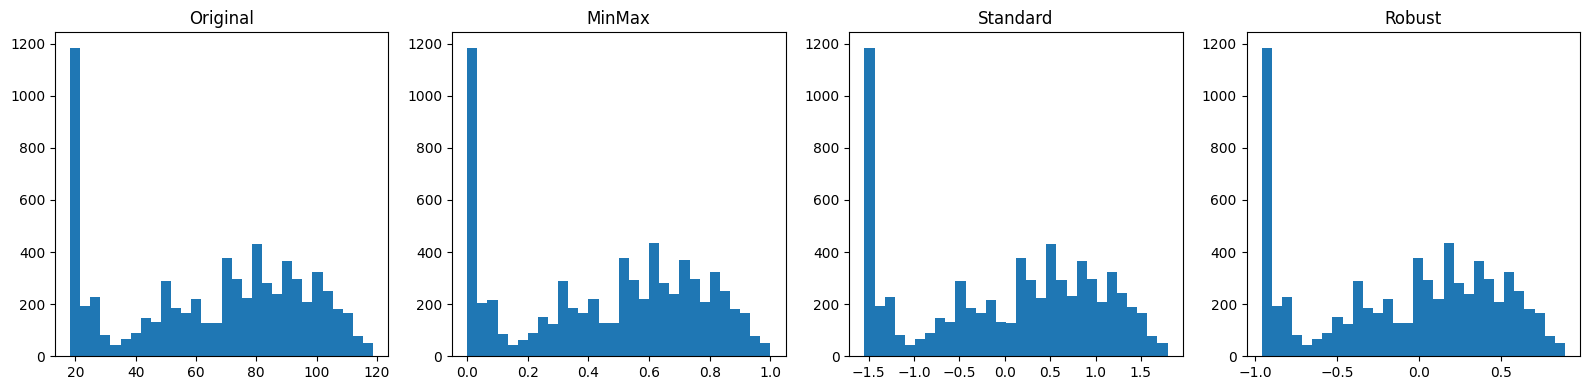

In [9]:
# Plot the original vs scaled distributions side by side.

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].hist(df['MonthlyCharges'], bins=30); ax[0].set_title('Original')
ax[1].hist(x_mm_df['MonthlyCharges'], bins=30); ax[1].set_title('MinMax')
ax[2].hist(x_std_df['MonthlyCharges'], bins=30); ax[2].set_title('Standard')
ax[3].hist(x_rb_df['MonthlyCharges'], bins=30); ax[3].set_title('Robust')
plt.tight_layout()
plt.show()

4 side-by-side histograms — same SHAPE but different x-axis scales.

StandardScaler → normal data

MinMaxScaler → bounded range needed

RobustScaler → outliers exist

In [10]:
# The leakage rule: split FIRST, scale SECOND
# Split, then fit_transform on TRAIN, transform on TEST.

from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(x, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_train)
print('Train mean:', x_train_s.mean(axis=0).round(2))
print('Test mean:', x_test_s.mean(axis=0).round(2))

Train mean: [-0.  0.]
Test mean: [-0.  0.]


Always split the data first, then fit the scaler on the training set and use that same scaler to transform both the training and test sets. This prevents data leakage and ensures a fair evaluation of the model.
The test data is a different sample, so after applying the training statistics, its mean is usually close to 0 but not exactly 0.

**Module 3 Homework 3**

**Categorical Encoding**

In [11]:
# List all object (text) columns
# select_dtypes() to filter

obj_cols=df.select_dtypes(include='object').columns.tolist()
print('Total object columns:', len(obj_cols))
print(obj_cols)

Total object columns: 17
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


We encode the text columns only

In [12]:
# value_counts on gender
# value_counts() - shows how the values are distributed

df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


There are 3555 male customers and 3488 female customers.

In [13]:
# One-hot encode InternetService with pd.get_dummies

dummies = pd.get_dummies(df['InternetService'], prefix='Internet')
print("Shape:", dummies.shape)
dummies.head()

Shape: (7043, 3)


,Internet_DSL,Internet_Fiber optic,Internet_No
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,False,True,False


In [14]:
# Now:
# (0,0) means DSL
# (1,0) means Fiber optic
# (0,1) means No
# The dropped category can still be identified because when
# all remaining columns are 0, it must belong to the missing category.

import pandas as pd
dummies2 = pd.get_dummies(df['InternetService'], prefix='Internet', drop_first = True)
print("With drop_first:", dummies2.shape)
dummies2.head()

With drop_first: (7043, 2)


,Internet_Fiber optic,Internet_No
0,False,False
1,False,False
2,False,False
3,False,False
4,True,False


In [15]:
# Use sklearn's OneHotEncoder.

from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['TechSupport']])
encoded_df=pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['TechSupport']))
encoded_df.head()

,TechSupport_No,TechSupport_No internet service,TechSupport_Yes
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0


pd.get_dummies() - short and easy

OneHotEncoder - good for  machine learning model with Scikit-Learn

In [16]:
# Binary Yes/No mapping
# 2 categories (Yes/No, Male/Female, True/False) → use mapping (0, 1)
# 3 or more categories (DSL/Fiber/No, Red/Blue/Green) → use one-hot encoding

df["Partner_bin"] = df["Partner"].map({'No':0, 'Yes':1})
df[['Partner', 'Partner_bin']].head()

,Partner,Partner_bin
0,Yes,1
1,No,0
2,No,0
3,No,0
4,No,0


In [17]:
# Encode many columns at once

multi = pd.get_dummies(df[['gender', 'InternetService', 'TechSupport', 'Contract']], drop_first=True)
print('Shape:', multi.shape)
multi.head()

Shape: (7043, 7)


,gender_Male,InternetService_Fiber optic,InternetService_No,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year
0,False,False,False,False,False,False,False
1,True,False,False,False,False,True,False
2,True,False,False,False,False,False,False
3,True,False,False,False,True,True,False
4,False,True,False,False,False,False,False


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Module 3 Homework 4

**Feature Selection** is the process of finding the most important features (columns) in a dataset. It checks which features help the model make better predictions and removes the less useful ones. This is important because training a model with all the features can take more time, use more memory, and sometimes even reduce the model's performance due to unnecessary or irrelevant features.

In [19]:
# Load and prepare

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_bin'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [20]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
# Build a feature set with numeric + one-hot encoded categorical

num = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
cat = pd.get_dummies(df[['Contract', 'PaymentMethod']], drop_first=True)
X = pd.concat([num, cat], axis=1)
Y = df['Churn_bin']
print('X shape:', X.shape)
print('Features:', list(X.columns))

X shape: (7043, 9)
Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [23]:
# Mutual information scores for all features

from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X, Y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_scores.round(4)

,0
tenure,0.0772
Contract_Two year,0.0546
MonthlyCharges,0.0432
TotalCharges,0.0431
PaymentMethod_Electronic check,0.0369
PaymentMethod_Credit card (automatic),0.0169
SeniorCitizen,0.0138
Contract_One year,0.0116
PaymentMethod_Mailed check,0.0008


MI score measures how much information a feature gives about the target. The higher the MI score, the more useful that feature is for making predictions.

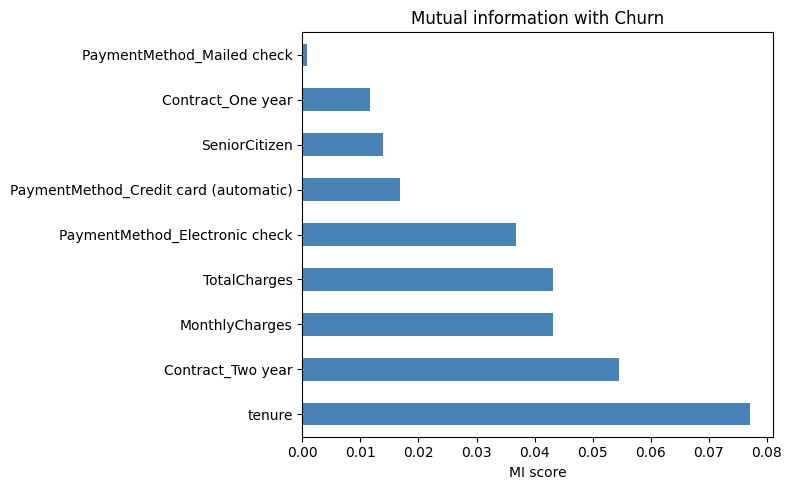

In [24]:
# Bar chart of MI scores

plt.figure(figsize=(8, 5))
mi_scores.plot(kind='barh', color='steelblue')
plt.title('Mutual information with Churn')
plt.xlabel('MI score')
plt.tight_layout()
plt.show()

In [25]:
# RFE — pick the top 3 features
# Use Logistic Regression to judge how useful each feature is.
# Remove the least useful feature.
# Repeat until only 3 features remain.
# Show which 3 features were selected.

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=3)
rfe.fit(X_scaled, Y)
result = pd.DataFrame({'feature': X.columns, 'kept':rfe.support_, 'rank':rfe.ranking_})
result.sort_values('rank')

,feature,kept,rank
0,tenure,True,1
1,MonthlyCharges,True,1
5,Contract_Two year,True,1
2,TotalCharges,False,2
4,Contract_One year,False,3
7,PaymentMethod_Electronic check,False,4
3,SeniorCitizen,False,5
8,PaymentMethod_Mailed check,False,6
6,PaymentMethod_Credit card (automatic),False,7


RFE is a method that repeatedly removes the least useful features until only the most important ones are left.

In [26]:
# Compare accuracy: all features vs top 3

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_tr, X_te, Y_tr, Y_te = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)
m_all = LogisticRegression(max_iter=1000).fit(X_tr, Y_tr)
print('All feature:', round(accuracy_score(Y_te, m_all.predict(X_te)), 4))
idx = np.where(rfe.support_)[0]
m_top = LogisticRegression(max_iter=1000).fit(X_tr[:, idx], Y_tr)
print('Top 3:', round(accuracy_score(Y_te, m_top.predict(X_te[:, idx])), 4))

All feature: 0.802
Top 3: 0.8006


This means the model predicted correctly 80.2% of the time by using all the features.
This means the model using only 3 features was correct 80.06% of the time.